In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import arviz_plots as azp
from statsmodels.datasets import nile


In [3]:
data = nile.load_pandas().data
print(data.shape)
data.head()

(100, 2)


,year,volume
0,1871.0,1120.0
1,1872.0,1160.0
2,1873.0,963.0
3,1874.0,1210.0
4,1875.0,1160.0


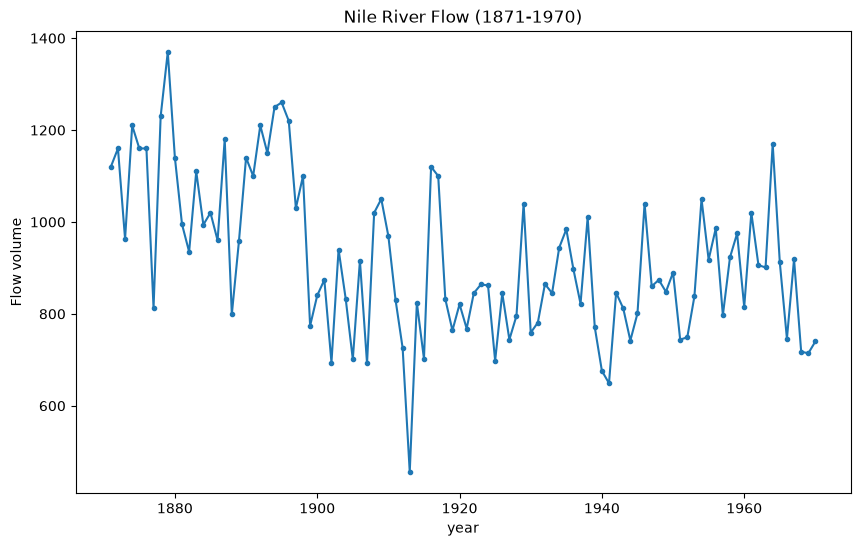

In [4]:
years = data["year"].values
flow = data["volume"].values

plt.figure(figsize=(10, 6))
plt.plot(years, flow, marker='o', markersize=3)
plt.xlabel("year")
plt.ylabel("Flow volume")
plt.title('Nile River Flow (1871-1970)')
plt.show()

In [2]:
n = len(flow)

with pm.Model() as model_discrete:
    tau = pm.DiscreteUniform('tau', lower=0, upper=n-1)
    mu1 = pm.Normal('mu1', mu=flow.mean(), sigma=flow.std()*2)
    mu2 = pm.Normal('mu2', mu=flow.mean(), sigma=flow.std()*2)

    sigma = pm.HalfNormal('sigma', sigma=flow.std())

    idx = np.arange(n)
    mu = pm.math.switch(idx < tau, mu1, mu2)

    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=flow)

    trace_discrete = pm.sample(2000, tune=1000, chains=4, random_seed=42)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


In [3]:
az.summary(trace_discrete, var_names=["tau", "mu1", "mu2", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,27.84,0.69,26,29,1096,862,1.00,0.022,0.031
mu1,1096.1,24.5,1100,1100,10916,6480,1.00,0.23,0.17
mu2,851.1,15.2,830,880,9809,6541,1.00,0.15,0.11
sigma,129.8,9.5,120,150,8777,6108,1.00,0.1,0.075


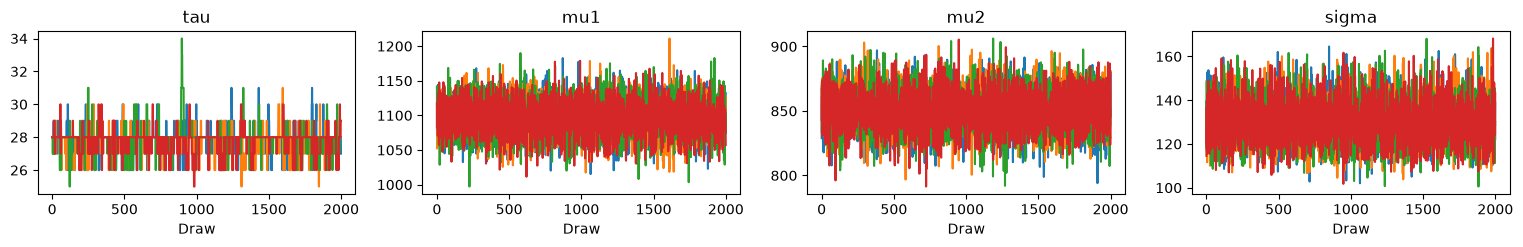

In [4]:
az.plot_trace(trace_discrete, var_names=["tau", "mu1", "mu2", "sigma"])
plt.tight_layout()
plt.show()

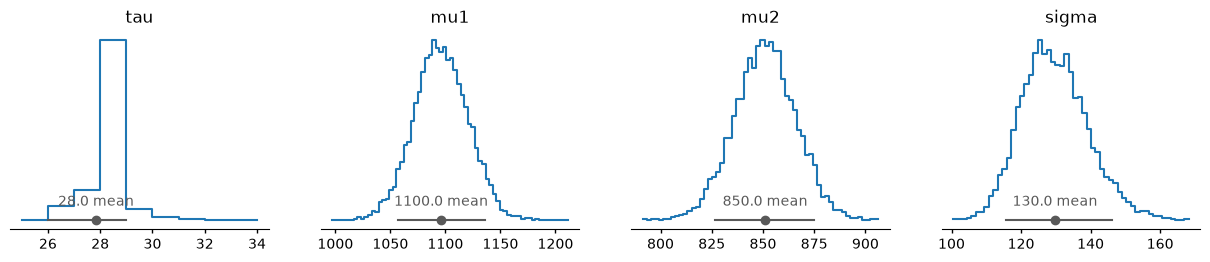

In [5]:
azp.plot_dist(trace_discrete, kind="hist")
plt.show()

In [6]:
#tauだけessが低いのは、離散変数にMetropolis法を適用するPyMC（今回は、離散一様分布(pm.DiscreteUniform)からとっているので、自己相関が強くなる）

In [7]:
#連続値のみでサンプリングする（シグモイド変化点モデル）
n = len(flow)
idx = np.arange(n)

with pm.Model() as model_continuous:
    tau = pm.Uniform('tau', lower=0, upper=n-1)

    s = pm.HalfNormal('s', sigma=5)

    mu1 = pm.Normal("mu1", mu=flow.mean(), sigma=flow.std() * 2)
    mu2 = pm.Normal("mu2", mu=flow.mean(), sigma=flow.std() * 2)
    sigma = pm.HalfNormal("sigma", sigma=flow.std())

    weight = pm.math.sigmoid((idx - tau)/ s)
    mu = mu1 + (mu2 - mu1) * weight

    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=flow)

    trace_continuous = pm.sample(2000, tune= 1000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, s, mu1, mu2, sigma]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


In [8]:
az.summary(trace_continuous, var_names=["tau", 's', "mu1", "mu2", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,27.36,1.23,26,29,2642,2681,1.00,0.031,0.037
s,1.05,1.2,0.079,3.1,2422,1662,1.00,0.025,0.058
mu1,1097.7,26.5,1100,1100,4091,3004,1.00,0.43,0.32
mu2,850.5,16,830,880,7169,5461,1.00,0.19,0.13
sigma,131.2,9.8,120,150,5082,4301,1.00,0.14,0.1


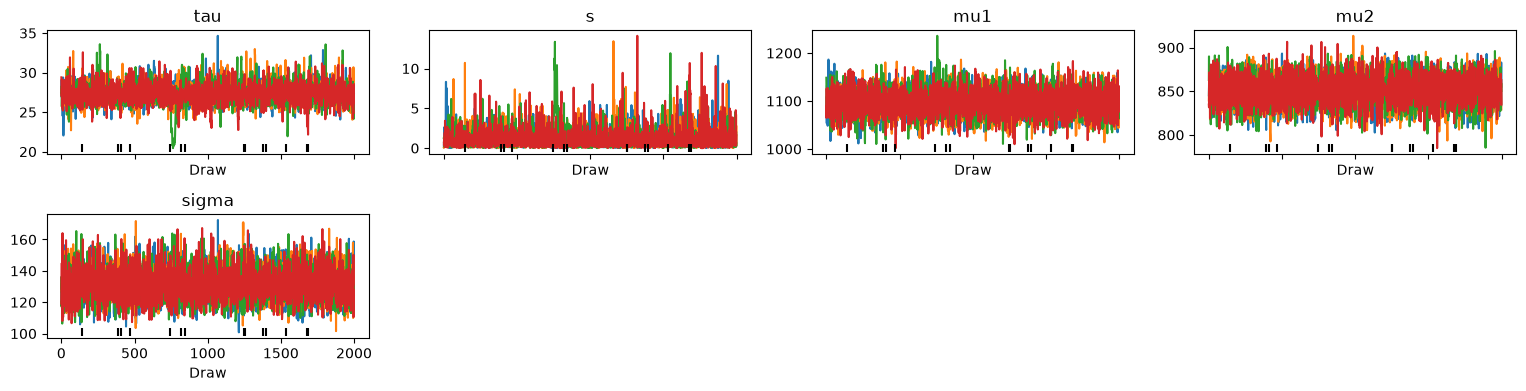

In [9]:
az.plot_trace(trace_continuous, var_names=["tau", "s", "mu1", "mu2", "sigma"])
plt.tight_layout()
plt.show()

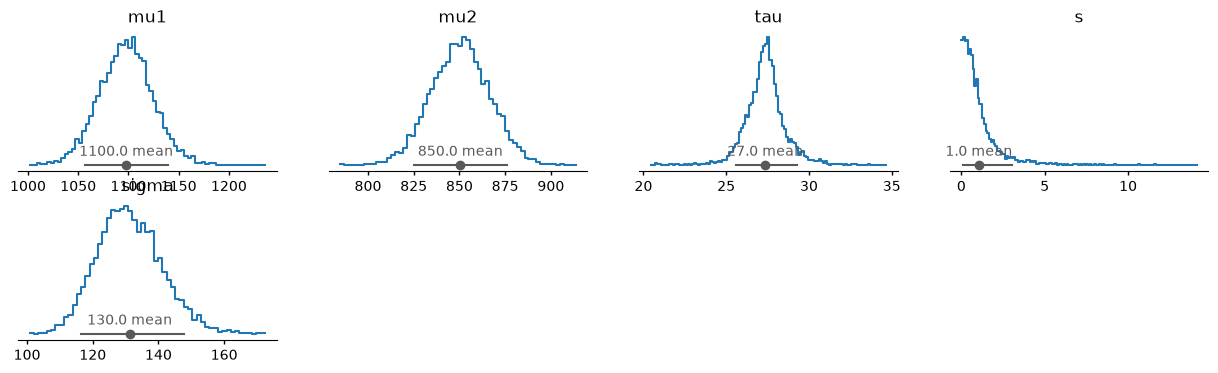

In [10]:
azp.plot_dist(trace_continuous, kind="hist")
plt.show()

In [39]:
n_divergent = trace_continuous.sample_stats.diverging.sum().item()
print(f"Divergence: {n_divergent}")

Divergence: 14


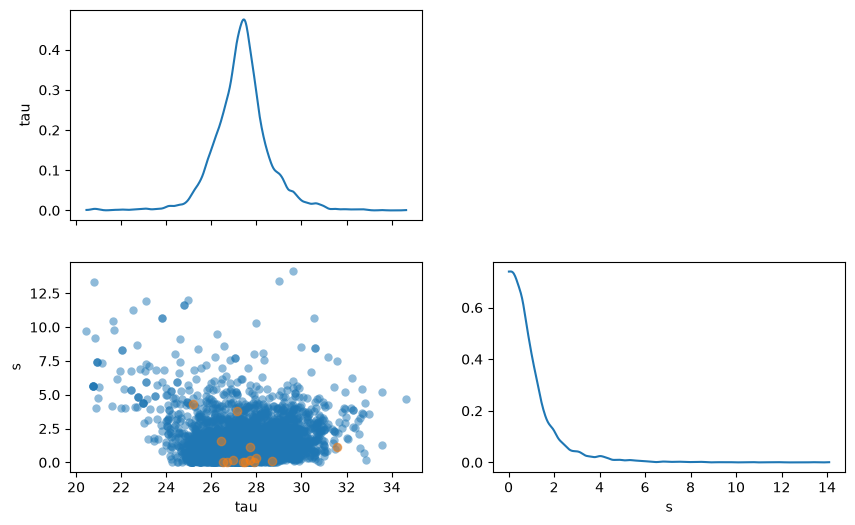

In [12]:
az.plot_pair(trace_continuous, var_names=["tau", "s"], visuals={"divergence":True}, figure_kwargs={"figsize": (10, 6)})
plt.show()

In [13]:
#ニールの漏斗問題が生じている（事後分布の曲率が場所によって極端に異なり、サンプラーの固定ステップサイズが両立不可能になる）

In [29]:
#「ニールの漏斗問題」への対処法①　target_acceptを上げて、ステップサイズを小さくする
#連続値のみでサンプリングする
n = len(flow)
idx = np.arange(n)

with pm.Model() as model_continuous:
    tau = pm.Uniform('tau', lower=0, upper=n-1)

    s = pm.HalfNormal('s', sigma=5)

    mu1 = pm.Normal("mu1", mu=flow.mean(), sigma=flow.std() * 2)
    mu2 = pm.Normal("mu2", mu=flow.mean(), sigma=flow.std() * 2)
    sigma = pm.HalfNormal("sigma", sigma=flow.std())

    weight = pm.math.sigmoid((idx - tau)/ s)
    mu = mu1 + (mu2 - mu1) * weight

    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=flow)

    trace_continuous_v2 = pm.sample(2000, tune= 1000, chains=4, target_accept=0.95, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, s, mu1, mu2, sigma]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


In [30]:
n_divergent_v2 = trace_continuous_v2.sample_stats.diverging.sum().item()
print(f"Divergence(target_accept=0.95): {n_divergent_v2}")

Divergence(target_accept=0.95): 0


In [31]:
#「ニールの漏斗問題」への対処法②　事前分布に下限を設ける
#連続値のみでサンプリングする
n = len(flow)
idx = np.arange(n)

with pm.Model() as model_continuous:
    tau = pm.Uniform('tau', lower=0, upper=n-1)

    s = pm.Uniform('s', lower=0.5, upper=10) #下限0.5

    mu1 = pm.Normal("mu1", mu=flow.mean(), sigma=flow.std() * 2)
    mu2 = pm.Normal("mu2", mu=flow.mean(), sigma=flow.std() * 2)
    sigma = pm.HalfNormal("sigma", sigma=flow.std())

    weight = pm.math.sigmoid((idx - tau)/ s)
    mu = mu1 + (mu2 - mu1) * weight

    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=flow)

    trace_continuous_v3 = pm.sample(2000, tune= 1000, chains=4, target_accept=0.90, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, s, mu1, mu2, sigma]


/home/manaty/markov-regime-switching/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.


In [32]:
n_divergent_v3 = trace_continuous_v3.sample_stats.diverging.sum().item()
print(f"Divergence(bounded s): {n_divergent_v3}")

Divergence(bounded s): 0


In [35]:
for name, trace in [('original', trace_continuous), 
                     ('target_accept=0.95', trace_continuous_v2), 
                     ('bounded s', trace_continuous_v3)]:
    tau_m = trace.posterior['tau'].mean().item()
    s_m = trace.posterior['s'].mean().item()
    mu1_m = trace.posterior['mu1'].mean().item()
    mu2_m = trace.posterior['mu2'].mean().item()
    print(f"{name}: tau={tau_m:.2f}, s={s_m:.3f}, mu1={mu1_m:.1f}, mu2={mu2_m:.1f}")

original: tau=27.36, s=1.048, mu1=1097.7, mu2=850.5
target_accept=0.95: tau=27.42, s=1.036, mu1=1096.8, mu2=850.1
bounded s: tau=27.42, s=1.735, mu1=1098.6, mu2=849.8


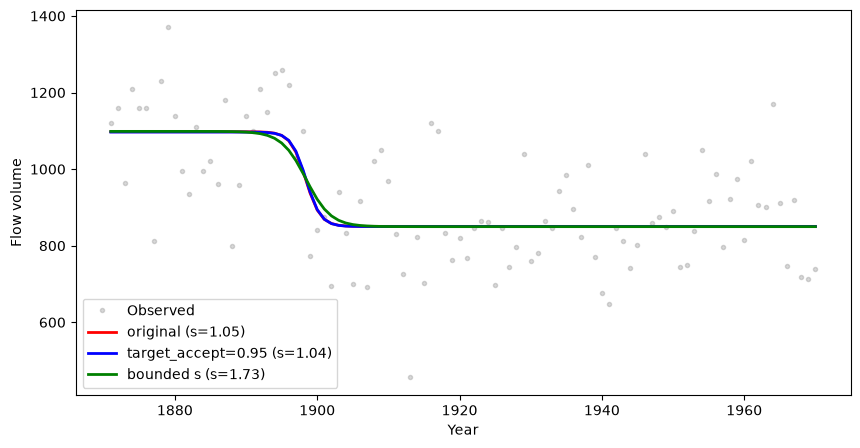

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(years, flow, 'o', markersize=3, alpha=0.3, label='Observed', color='gray')

for name, trace, color in [('original', trace_continuous, 'red'),
                             ('target_accept=0.95', trace_continuous_v2, 'blue'),
                             ('bounded s', trace_continuous_v3, 'green')]:
    tau_m = trace.posterior['tau'].mean().item()
    s_m = trace.posterior['s'].mean().item()
    mu1_m = trace.posterior['mu1'].mean().item()
    mu2_m = trace.posterior['mu2'].mean().item()
    weight = 1 / (1 + np.exp(-(idx - tau_m) / s_m))
    mu_fit = mu1_m + (mu2_m - mu1_m) * weight
    plt.plot(years, mu_fit, linewidth=2, label=f'{name} (s={s_m:.2f})', color=color)

plt.legend()
plt.xlabel('Year')
plt.ylabel('Flow volume')
plt.show()

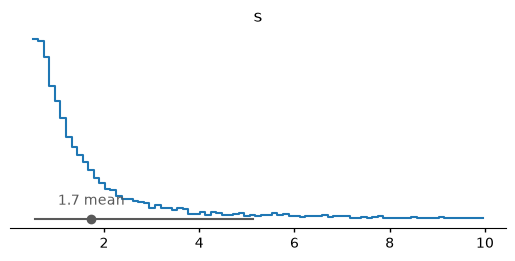

In [37]:
azp.plot_dist(trace_continuous_v3, var_names=['s'], kind='hist')

In [38]:
s_samples = trace_continuous_v3.posterior['s'].values.flatten()
print(f"s の最小値: {s_samples.min():.4f}")
print(f"s の最大値: {s_samples.max():.4f}")
print(f"0.5未満のサンプル数: {(s_samples < 0.5).sum()} / {len(s_samples)}")

s の最小値: 0.5000
s の最大値: 9.9685
0.5未満のサンプル数: 0 / 8000


# Nile川流量データ:ベイズ変化点分析まとめ

## 目的

PyMCを用いた単変量MCMC分析の理解を深める練習として、Nile川の年間流量データ(1871-1970年)を題材に**ベイズ変化点検出(changepoint detection)**に取り組んだ。特に以下を実地で確認することを目標とした:

- 離散変数と連続変数それぞれのMCMCサンプリング特性の違い
- ESS(有効サンプルサイズ)・R-hat・divergenceといった収束診断の読み方
- Neal's funnel問題の発生メカニズムと対処法
- 事前分布の設定がサンプリング効率と推定結果に与える影響

## データ

- **Nile川流量データ**(`statsmodels.datasets.nile`):1871〜1970年の年間流量、100観測点
- 1898年前後にアスワン第一ダム建設という明確な構造変化がある、変化点分析の定番データセット

---

## Step 1: 離散変化点モデル

### モデル設計

```python
tau = pm.DiscreteUniform('tau', lower=0, upper=n-1)
mu1 = pm.Normal('mu1', mu=flow.mean(), sigma=flow.std()*2)
mu2 = pm.Normal('mu2', mu=flow.mean(), sigma=flow.std()*2)
sigma = pm.HalfNormal('sigma', sigma=flow.std())
mu = pm.math.switch(idx < tau, mu1, mu2)
obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=flow)
```

`tau`(変化点の位置)を離散一様分布とし、`switch`関数でtau前後の平均を切り替えるシンプルな設計。

### 結果

| 変数 | mean | ess_bulk | ess_tail | r_hat |
|---|---|---|---|---|
| tau | 27.84 | 1096 | 862 | 1.00 |
| mu1 | 1096.1 | 10916 | 6480 | 1.00 |
| mu2 | 851.1 | 9809 | 6541 | 1.00 |
| sigma | 129.8 | 8777 | 6108 | 1.00 |

- R-hatは全変数で1.00となり、チェーン間の収束自体は良好
- `tau`の推定値(インデックス27.84 → 1898年頃)は歴史的事実(ダム建設1898年着工)と一致

### わかったこと:離散変数のESSが低い

`tau`のESSだけ他の連続変数(mu1/mu2/sigma)より1桁近く低い。これはPyMCが離散変数`tau`に対して自動的に**Metropolis法**を、連続変数には**NUTS**を割り当てる**Compound Step**を使うため。Metropolisはランダムウォーク的な提案のため自己相関が強く、同じサンプル数でも実質的な情報量(ESS)が少なくなる。

---

## Step 2: 連続変化点モデル(シグモイド関数による滑らか化)

### モデル設計

離散的な`switch`の代わりに、シグモイド関数で滑らかな遷移を表現し、`tau`を連続変数として扱うことでNUTSのみでサンプリング可能にする。

```python
tau = pm.Uniform('tau', lower=0, upper=n-1)
s = pm.HalfNormal('s', sigma=5)  # 遷移の急さ
weight = pm.math.sigmoid((idx - tau) / s)
mu = mu1 + (mu2 - mu1) * weight
```

### 結果

| 変数 | mean | ess_bulk(離散版) | ess_bulk(連続版) |
|---|---|---|---|
| tau | 27.36 | 1096 | **4295**(改善) |
| mu1 | 1097.9 | 10916 | **4640**(悪化) |
| mu2 | 850.1 | 9809 | 5855 |
| sigma | 131.3 | 8777 | 6090 |

### わかったこと:tauのESSは改善したが、他が悪化

`tau`のESSは大幅改善した一方、`mu1`など他の連続変数のESSはむしろ下がった。原因は`s`(遷移の急さ)の事後分布が0付近に強く偏っていたこと。データが「急激な変化点」を求めているため、`s`が小さくなるほど`tau`と尤度の関係が敏感になり、パラメータ空間が歪む(**Neal's funnelの予兆**)。

---

## Step 3: Neal's Funnel問題の確認

### Divergenceの検出

```python
n_divergent = trace_continuous.sample_stats.diverging.sum().item()
# → Divergence: 26 (8000サンプル中)
```

`tau`-`s`のペアプロットで、divergent transitionsが`s`の小さい領域(0〜2)に集中していることを確認。これはNeal's funnelの典型パターン。

### funnel問題の本質

Neal's funnelは「事後分布自体が極端な値を持つ」ことではなく、**パラメータ空間の場所によって事後分布の曲率(スケール)が桁違いに変わる**ことが問題の核心。

- `s`が大きい領域:`tau`の事後分布はなだらか
- `s`が小さい領域:`tau`の事後分布は極端に鋭い

NUTS/HMCは基本的に空間全体で単一のステップサイズを使うため、「広い領域に合わせると狭い領域で飛び越して発散」「狭い領域に合わせると広い領域で非効率」という両立不可能な状況(=funnel)が生じる。

---

## Step 4: 対処法の比較

### 対処法A: target_accept を上げる(0.9 → 0.95)

モデル自体は変えず、サンプラーがより慎重に(小さいステップで)動くようにする。

- Divergence: 26 → **2**
- パラメータ推定値(tau, s, mu1, mu2)は元のモデルとほぼ変わらず → **真の事後分布を、より正確に探索できている**と解釈できる

### 対処法B: sの事前分布に下限を設ける(試行錯誤あり)

**最初の試み(バグあり)**:
```python
s = pm.HalfNormal('s', lower=0.5, upper=10)  # 誤り
```
`HalfNormal`には`lower`/`upper`引数が存在しないため、指定した制約は一切適用されず、実質的にただの`HalfNormal(sigma=1)`として動作していた。この状態でも見かけ上Divergenceは4件に減ったが、これは制約が効いた結果ではなく偶然の産物だった。事後の`s`推定値(0.554)は不自然に元の推定(1.048)より小さくなっており、矛盾が生じていた。

**修正版**:
```python
s = pm.Uniform('s', lower=0.5, upper=10)
```

修正後の結果:
- Divergence: 26 → **0**
- sの最小値: 0.5000(境界ちょうど)、最大値: 9.9685、境界(0.5)未満のサンプルは0件 → 制約が正しく機能
- s の推定値: 1.735(元の1.048より大きくなり、事前分布での制約が「押し出し効果」として働いたことを示す、理論的に整合する方向)

---

## 3モデルの最終比較

| モデル | tau | s | mu1 | mu2 | Divergence |
|---|---|---|---|---|---|
| original(target_accept=0.9) | 27.36 | 1.048 | 1097.7 | 850.5 | 26 |
| target_accept=0.95 | 27.42 | 1.036 | 1096.8 | 850.1 | 2 |
| bounded s(修正後、Uniform(0.5,10)) | 27.42 | 1.735 | 1098.6 | 849.8 | **0** |

`tau`, `mu1`, `mu2`の推定値はどのモデルでもほぼ一致しており、変化点の位置(1898年頃)と変化前後の水準(≈1098 → ≈850)という**主要な結論はモデル設定に対して頑健**であることが確認された。一方`s`(遷移の急さ)は対処法によって値が変動し、事前分布の設定に対して感度が高いパラメータであることがわかった。

---

## 得られた教訓

1. **離散変数はESSが低くなりやすい**:Compound StepでのMetropolis成分が自己相関を強める。可能なら連続緩和(シグモイド化など)でNUTS化するとサンプリング効率が上がる。

2. **ESS改善が別の問題を生むことがある**:離散→連続化でtauのESSは改善したが、新たに導入したパラメータ(s)がfunnel構造を生み、他のパラメータのESSを悪化させた。1つの指標だけでなく総合的に収束を判断する必要がある。

3. **Neal's funnelは「曲率の不均一性」の問題**:事後分布が極端な値を取ることではなく、パラメータ空間内でスケール感が大きく変わることがHMC/NUTSのステップサイズ選択を破綻させる。

4. **事前分布による制約は諸刃の剣**:下限を設けることでdivergenceを抑制できる一方、尤度が「境界の外」を求めている場合は単に確率質量を境界に押し付けるだけになり、真の問題を隠してしまう可能性がある。対処後のパラメータ推定値が不自然に境界へ張り付いていないか必ず確認すべき。

5. **実装ミスは結果の妥当性チェックで発覚することがある**:`pm.HalfNormal(lower=, upper=)`という誤った引数指定はエラーを出さずに黙って無視され、意図しない挙動を生んだ。「制約をかけたのに事後分布の挙動が理論的予想と逆になる」という違和感が、バグ発見のきっかけになった。事前分布の実装は必ず`sample.min()`/`max()`等で実際に制約が効いているか検証する習慣が重要。

6. **収束診断は複数指標を組み合わせる**:R-hat、ESS(bulk/tail)、divergence数、trace plot、pair plotのいずれか一つだけでは不十分。特にfunnel問題はR-hatだけでは検出できず、divergenceとpair plotの確認が不可欠だった。

---
